In [2]:
import pandas as pd
import pickle
from collections import defaultdict
from pathlib import Path

In [55]:
# =========================
# 1. 设置文件路径
# =========================

refgene_path = Path("extra/datasets/annotations/refGene.tsv")        # 或者 "refGene(1).tsv"
ensg2tss_path = Path("extra/datasets/annotations/ensg2tss.pickle")

In [56]:
# =========================
# 2. 读取 refGene 和 ensg2tss
# =========================

refgene = pd.read_csv(refgene_path, sep="\t")

with open(ensg2tss_path, "rb") as f:
    ensg2tss = pickle.load(f)

print("refGene rows:", len(refgene))
print("refGene genes:", refgene["ensg"].nunique())
print("ensg2tss genes:", len(ensg2tss))
print("ensg2tss total TSS:", sum(len(v) for v in ensg2tss.values()))

refGene rows: 64386
refGene genes: 18955
ensg2tss genes: 18955
ensg2tss total TSS: 64386


In [8]:
# =========================
# 3. 从 refGene 按唯一规则重建 ensg2tss
# 
# 规则：
#   + strand: TSS = (chrom, txStart - 1, txStart, "+")
#   - strand: TSS = (chrom, txEnd, txEnd + 1, "-")
# =========================

rebuilt_ensg2tss = defaultdict(list)

for row in refgene.itertuples(index=False):
    ensg = row.ensg
    chrom = row.chrom
    strand = row.strand
    tx_start = int(row.txStart)
    tx_end = int(row.txEnd)

    if strand == "+":
        tss = (chrom, tx_start - 1, tx_start, "+")
    elif strand == "-":
        tss = (chrom, tx_end, tx_end + 1, "-")
    else:
        raise ValueError(f"Unknown strand: {strand}")

    rebuilt_ensg2tss[ensg].append(tss)

rebuilt_ensg2tss = dict(rebuilt_ensg2tss)

print("rebuilt genes:", len(rebuilt_ensg2tss))
print("rebuilt total TSS:", sum(len(v) for v in rebuilt_ensg2tss.values()))

rebuilt genes: 18955
rebuilt total TSS: 64386


In [9]:
# =========================
# 4. 标准化原始 ensg2tss，避免 int 类型或 defaultdict 差异影响比较
# =========================

ensg2tss_norm = {}

for ensg, tss_list in ensg2tss.items():
    ensg2tss_norm[ensg] = [
        (str(chrom), int(start), int(end), str(strand))
        for chrom, start, end, strand in tss_list
    ]

In [10]:
# =========================
# 5. 逐 gene、逐 TSS 比对
# =========================

all_genes = sorted(set(rebuilt_ensg2tss.keys()) | set(ensg2tss_norm.keys()))

n_gene_exact = 0
n_tss_exact = 0
n_tss_total = 0

mismatch_records = []

for ensg in all_genes:
    rebuilt = rebuilt_ensg2tss.get(ensg, [])
    original = ensg2tss_norm.get(ensg, [])

    if rebuilt == original:
        n_gene_exact += 1
    else:
        mismatch_records.append({
            "ensg": ensg,
            "rebuilt_n_tss": len(rebuilt),
            "original_n_tss": len(original),
            "rebuilt_first_5": rebuilt[:5],
            "original_first_5": original[:5],
        })

    n_tss_total += len(original)

    for a, b in zip(rebuilt, original):
        if a == b:
            n_tss_exact += 1

print("Gene exact match:", f"{n_gene_exact} / {len(all_genes)}")
print("TSS exact match:", f"{n_tss_exact} / {n_tss_total}")
print("Number of mismatched genes:", len(mismatch_records))

Gene exact match: 18955 / 18955
TSS exact match: 64386 / 64386
Number of mismatched genes: 0


In [11]:
# =========================
# 6. 查看是否 100% 复现
# =========================

if n_gene_exact == len(all_genes) and n_tss_exact == n_tss_total and len(mismatch_records) == 0:
    print("✅ 结论：该规则可以 100% 复现 ensg2tss.pickle")
    print('规则：+ strand 使用 (chrom, txStart - 1, txStart, "+")')
    print('规则：- strand 使用 (chrom, txEnd, txEnd + 1, "-")')
else:
    print("❌ 结论：该规则不能完全复现 ensg2tss.pickle")
    print("前几个 mismatch：")
    display(pd.DataFrame(mismatch_records).head())

✅ 结论：该规则可以 100% 复现 ensg2tss.pickle
规则：+ strand 使用 (chrom, txStart - 1, txStart, "+")
规则：- strand 使用 (chrom, txEnd, txEnd + 1, "-")


# multi TSS analysis

In [5]:
import pickle
import numpy as np
ensg2tss_path = Path("extra/datasets/annotations/ensg2tss.pickle")

with open(ensg2tss_path, "rb") as f:
    ensg2tss = pickle.load(f)

ensg2tss

defaultdict(list,
            {'ENSG00000000003': [('chrX', 99891803, 99891804, '-'),
              ('chrX', 99892101, 99892102, '-'),
              ('chrX', 99892101, 99892102, '-'),
              ('chrX', 99892101, 99892102, '-'),
              ('chrX', 99891803, 99891804, '-')],
             'ENSG00000000005': [('chrX', 99839931, 99839932, '+')],
             'ENSG00000000419': [('chr20', 49575101, 49575102, '-'),
              ('chr20', 49575101, 49575102, '-'),
              ('chr20', 49575101, 49575102, '-'),
              ('chr20', 49575069, 49575070, '-'),
              ('chr20', 49575101, 49575102, '-')],
             'ENSG00000000457': [('chr1', 169863037, 169863038, '-'),
              ('chr1', 169863100, 169863101, '-')],
             'ENSG00000000460': [('chr1', 169764179, 169764180, '+'),
              ('chr1', 169764138, 169764139, '+'),
              ('chr1', 169764179, 169764180, '+'),
              ('chr1', 169763869, 169763870, '+'),
              ('chr1', 169764138,

In [13]:
len(ensg2tss)

18955

In [ ]:
rows = []

for gene_id, tss_list in ensg2tss.items():
    if len(tss_list) == 0:
        continue

    # 按完整 TSS tuple 去重，并保持原始顺序
    unique_tss_list = []
    seen = set()

    for item in tss_list:
        chrom, start, end, strand = item
        key = (chrom, int(start), int(end), strand)

        if key in seen:
            continue

        seen.add(key)
        unique_tss_list.append(key)

    if len(unique_tss_list) == 0:
        continue

    # 第一个 unique TSS 作为 reference TSS
    first_chrom, first_start, first_end, first_strand = unique_tss_list[0]
    first_tss = int(first_start)

    distances = []

    # 从第二个 unique TSS 开始计算距离
    for chrom, start, end, strand in unique_tss_list[1:]:
        # 只比较同一染色体、同一链
        if chrom != first_chrom or strand != first_strand:
            continue

        tss = int(start)
        abs_distance = abs(tss - first_tss)
        distances.append(abs_distance)

    # 如果只有一个 unique TSS，或者后续 TSS 都不在同一染色体/同一链，则距离设为 0
    if len(distances) == 0:
        mean_dist = 0
        median_dist = 0
        max_dist = 0
    else:
        mean_dist = np.mean(distances)
        median_dist = np.median(distances)
        max_dist = np.max(distances)

    rows.append({
        "gene_id": gene_id,
        "n_tss_raw": len(tss_list),
        "n_tss_unique": len(unique_tss_list),
        "n_compared_tss": len(distances),
        "first_chrom": first_chrom,
        "first_strand": first_strand,
        "first_tss": first_tss,
        "mean_abs_distance_to_first_tss_bp": mean_dist,
        "median_abs_distance_to_first_tss_bp": median_dist,
        "max_abs_distance_to_first_tss_bp": max_dist,
    })

gene_tss_distance = pd.DataFrame(rows)

gene_tss_distance = gene_tss_distance.sort_values(
    "mean_abs_distance_to_first_tss_bp",
    ascending=False
).reset_index(drop=True)

gene_tss_distance

meta_data = pd.read_csv('./extra/datasets/processed/v2/meta_datasets/meta_data_E003.csv')[['gene_id','expression']]

gene_tss_distance = pd.merge(gene_tss_distance,meta_data,on='gene_id')

,gene_id,n_tss_raw,n_tss_unique,n_compared_tss,first_chrom,first_strand,first_tss,mean_abs_distance_to_first_tss_bp,median_abs_distance_to_first_tss_bp,max_abs_distance_to_first_tss_bp
0,ENSG00000205944,3,2,1,chrY,+,26979988,1614386.0,1614386.0,1614386
1,ENSG00000152042,19,2,1,chr1,-,147624560,1541836.0,1541836.0,1541836
2,ENSG00000204179,58,6,5,chr10,-,46641045,1312152.6,2186595.0,2186921
3,ENSG00000172264,5,2,1,chr20,+,15177484,1201324.0,1201324.0,1201324
4,ENSG00000150672,27,9,8,chr11,-,85338388,1164055.5,1249773.5,1945057
...,...,...,...,...,...,...,...,...,...,...
18950,ENSG00000143006,1,1,0,chr1,+,53925070,0.0,0.0,0
18951,ENSG00000143028,1,1,0,chr1,+,110009166,0.0,0.0,0
18952,ENSG00000143032,1,1,0,chr1,-,91182859,0.0,0.0,0
18953,ENSG00000143067,1,1,0,chr1,-,120190889,0.0,0.0,0


In [27]:
meta_data = pd.read_csv('./extra/datasets/processed/v2/meta_datasets/meta_data_E003.csv')[['gene_id','expression']]

gene_tss_distance = pd.merge(gene_tss_distance,meta_data,on='gene_id')

In [28]:
gene_tss_distance

,gene_id,n_tss_raw,n_tss_unique,n_compared_tss,first_chrom,first_strand,first_tss,mean_abs_distance_to_first_tss_bp,median_abs_distance_to_first_tss_bp,max_abs_distance_to_first_tss_bp,mean_abs_distance_bin,expression
0,ENSG00000205944,3,2,1,chrY,+,26979988,1614386.0,1614386.0,1614386,>20000,0.000000
1,ENSG00000204179,58,6,5,chr10,-,46641045,1312152.6,2186595.0,2186921,>20000,0.059347
2,ENSG00000172264,5,2,1,chr20,+,15177484,1201324.0,1201324.0,1201324,>20000,0.350148
3,ENSG00000150672,27,9,8,chr11,-,85338388,1164055.5,1249773.5,1945057,>20000,0.225519
4,ENSG00000108684,2,2,1,chr17,-,32483825,863512.0,863512.0,863512,>20000,0.522255
...,...,...,...,...,...,...,...,...,...,...,...,...
14415,ENSG00000143006,1,1,0,chr1,+,53925070,0.0,0.0,0,<=500,0.077151
14416,ENSG00000143028,1,1,0,chr1,+,110009166,0.0,0.0,0,<=500,0.041543
14417,ENSG00000143032,1,1,0,chr1,-,91182859,0.0,0.0,0,<=500,0.002967
14418,ENSG00000143067,1,1,0,chr1,-,120190889,0.0,0.0,0,<=500,1.157270


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_18426/2561957525.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gene_tss_distance[['mean_abs_distance_to_first_tss_bp']])


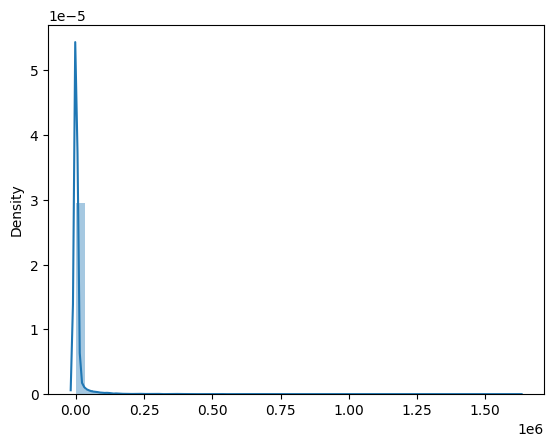

In [29]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.distplot(gene_tss_distance[['mean_abs_distance_to_first_tss_bp']])
plt.show()

In [30]:
import pandas as pd

# 阈值分组：左闭右开/右闭这里用 <= 解释更直观
bins = [-1, 500, 1000, 2000, 5000, 10000, 20000, float("inf")]
labels = [
    "<=500",
    "500-1000",
    "1000-2000",
    "2000-5000",
    "5000-10000",
    "10000-20000",
    ">20000",
]

gene_tss_distance["mean_abs_distance_bin"] = pd.cut(
    gene_tss_distance["mean_abs_distance_to_first_tss_bp"],
    bins=bins,
    labels=labels,
    right=True
)

threshold_summary = (
    gene_tss_distance["mean_abs_distance_bin"]
    .value_counts()
    .reindex(labels)
    .reset_index()
)

threshold_summary.columns = ["mean_abs_distance_bin", "gene_count"]
threshold_summary["fraction"] = (
    threshold_summary["gene_count"] / threshold_summary["gene_count"].sum()
)

threshold_summary

,mean_abs_distance_bin,gene_count,fraction
0,<=500,11602,0.804577
1,500-1000,561,0.038904
2,1000-2000,319,0.022122
3,2000-5000,382,0.026491
4,5000-10000,331,0.022954
5,10000-20000,340,0.023578
6,>20000,885,0.061373


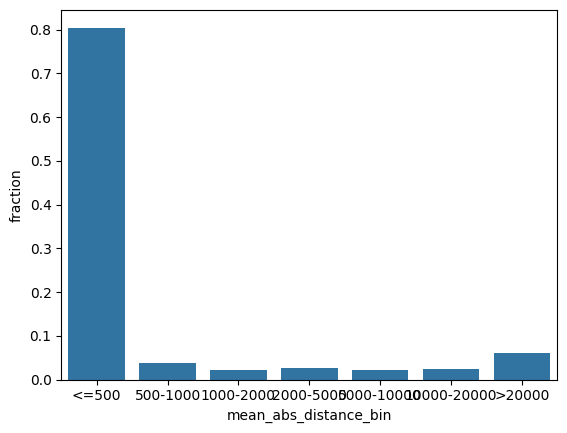

In [31]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.barplot(threshold_summary,x='mean_abs_distance_bin',y='fraction')
plt.show()

In [37]:
import pandas as pd

rows = []

for gene_id, tss_list in ensg2tss.items():
    # 按完整 tuple 去重，并保持原始顺序
    unique_tss_list = []
    seen = set()

    for item in tss_list:
        chrom, start, end, strand = item
        key = (chrom, int(start), int(end), strand)

        if key in seen:
            continue

        seen.add(key)
        unique_tss_list.append(key)

    rows.append({
        "gene_id": gene_id,
        "n_tss_raw": len(tss_list),
        "n_tss_unique": len(unique_tss_list),
    })

tss_count_df = pd.DataFrame(rows)

tss_count_df = tss_count_df.sort_values(
    ["n_tss_unique", "n_tss_raw"],
    ascending=[False, False]
).reset_index(drop=True)



tss_count_df = pd.merge(tss_count_df,meta_data,on='gene_id')
tss_count_df

,gene_id,n_tss_raw,n_tss_unique,expression
0,ENSG00000196628,46,14,14.569733
1,ENSG00000048740,36,12,5.074184
2,ENSG00000022267,16,12,5.448071
3,ENSG00000172995,59,11,0.000000
4,ENSG00000196482,20,11,0.192878
...,...,...,...,...
14415,ENSG00000259511,1,1,0.020772
14416,ENSG00000259518,1,1,0.000000
14417,ENSG00000259571,1,1,0.000000
14418,ENSG00000259642,1,1,0.575668


In [52]:
tss_count_df[tss_count_df['n_tss_unique']>5]

,gene_id,n_tss_raw,n_tss_unique,expression
0,ENSG00000196628,46,14,14.569733
1,ENSG00000048740,36,12,5.074184
2,ENSG00000022267,16,12,5.448071
3,ENSG00000172995,59,11,0.000000
4,ENSG00000196482,20,11,0.192878
...,...,...,...,...
126,ENSG00000132507,6,6,121.065282
127,ENSG00000160179,6,6,0.151335
128,ENSG00000169813,6,6,21.403561
129,ENSG00000170315,6,6,17.270030


In [50]:
ensg2tss['ENSG00000048740']

[('chr10', 11206991, 11206992, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11206991, 11206992, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10504511, 10504512, '+'),
 ('chr10', 10838800, 10838801, '+'),
 ('chr10', 10838800, 10838801, '+'),
 ('chr10', 10840686, 10840687, '+'),
 ('chr10', 10840686, 10840687, '+'),
 ('chr10', 10840686, 10840687, '+'),
 ('chr10', 11046609, 11046610, '+'),
 ('chr10', 11046609, 11046610, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047273, 11047274, '+'),
 ('chr10', 11047620, 11047621, '+'),
 ('chr10', 11047620, 11047621, '+'),
 ('chr10', 11059833, 11059834, '+'),
 ('chr10', 11059833, 11059834, '+'),
 

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

tss_count_summary = (
    tss_count_df["n_tss_unique"]
    .value_counts()
    .sort_index()
    .reset_index()
)

tss_count_summary.columns = ["n_tss_unique", "gene_count"]
tss_count_summary["fraction"] = (
    tss_count_summary["gene_count"] / tss_count_summary["gene_count"].sum()
)

tss_count_summary

,n_tss_unique,gene_count,fraction
0,1,8969,0.621983
1,2,3568,0.247434
2,3,1172,0.081276
3,4,412,0.028571
4,5,168,0.011650
5,6,60,0.004161
6,7,29,0.002011
7,8,16,0.001110
8,9,14,0.000971
9,10,5,0.000347


In [42]:
plot_df = tss_count_df.copy()

plot_df["n_tss_group"] = plot_df["n_tss_unique"].apply(
    lambda x: str(x) if x < 6 else ">5"
)

# 固定显示顺序
order = ["1", "2", "3", "4", "5", ">5"]

plot_df["n_tss_group"] = pd.Categorical(
    plot_df["n_tss_group"],
    categories=order,
    ordered=True
)

pie_df = (
    plot_df
    .groupby("n_tss_group", observed=False)
    .agg(
        gene_count=("gene_id", "count"),
        mean_expression=("expression", "mean"),
        median_expression=("expression", "median"),
    )
    .reset_index()
)

pie_df["fraction"] = pie_df["gene_count"] / pie_df["gene_count"].sum()

pie_df = pie_df.sort_values("n_tss_group").reset_index(drop=True)

pie_df

,n_tss_group,gene_count,mean_expression,median_expression,fraction
0,1,8969,5.412559,0.353116,0.621983
1,2,3568,6.824586,2.007418,0.247434
2,3,1172,8.556041,2.166172,0.081276
3,4,412,8.217013,2.548961,0.028571
4,5,168,5.857655,1.951039,0.011650
5,>5,131,7.911228,2.545994,0.009085


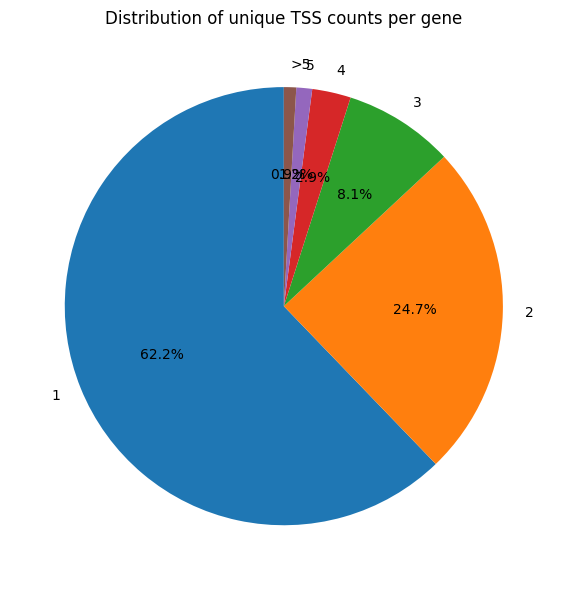

In [41]:
plt.figure(figsize=(6, 6))

plt.pie(
    pie_df["gene_count"],
    labels=pie_df["n_tss_group"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of unique TSS counts per gene")
plt.tight_layout()
plt.show()

In [36]:
gene_tss_distance

,gene_id,n_tss_raw,n_tss_unique,n_compared_tss,first_chrom,first_strand,first_tss,mean_abs_distance_to_first_tss_bp,median_abs_distance_to_first_tss_bp,max_abs_distance_to_first_tss_bp,mean_abs_distance_bin,expression
0,ENSG00000205944,3,2,1,chrY,+,26979988,1614386.0,1614386.0,1614386,>20000,0.000000
1,ENSG00000204179,58,6,5,chr10,-,46641045,1312152.6,2186595.0,2186921,>20000,0.059347
2,ENSG00000172264,5,2,1,chr20,+,15177484,1201324.0,1201324.0,1201324,>20000,0.350148
3,ENSG00000150672,27,9,8,chr11,-,85338388,1164055.5,1249773.5,1945057,>20000,0.225519
4,ENSG00000108684,2,2,1,chr17,-,32483825,863512.0,863512.0,863512,>20000,0.522255
...,...,...,...,...,...,...,...,...,...,...,...,...
14415,ENSG00000143006,1,1,0,chr1,+,53925070,0.0,0.0,0,<=500,0.077151
14416,ENSG00000143028,1,1,0,chr1,+,110009166,0.0,0.0,0,<=500,0.041543
14417,ENSG00000143032,1,1,0,chr1,-,91182859,0.0,0.0,0,<=500,0.002967
14418,ENSG00000143067,1,1,0,chr1,-,120190889,0.0,0.0,0,<=500,1.157270


In [8]:
import pandas as pd
import pickle
from collections import defaultdict

# ===========================
# Input / Output
# ===========================
refgene_path = Path("extra/datasets/annotations/refGene.tsv")        # 或者 "refGene(1).tsv"
output_path = "/mnt/data/ensg2tss_sorted_by_length.pickle"

# ===========================
# Load refGene table
# ===========================
df = pd.read_csv(refgene_path, sep="\t")
df.columns = df.columns.str.strip()  # 清理列名空格
required_cols = ['ensg', 'name', 'chrom', 'strand', 'txStart', 'txEnd']

# 保证列存在
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing column {c} in refGene.tsv")

# 转为 int
df['txStart'] = df['txStart'].astype(int)
df['txEnd'] = df['txEnd'].astype(int)

# 去掉 ENSG 版本号，例如 ENSG000001.1 -> ENSG000001
df['ensg'] = df['ensg'].astype(str).str.split('.').str[0]

# 计算 transcript length
df['transcript_length'] = df['txEnd'] - df['txStart']

# ===========================
# 按转录本长度排序
# ===========================
df = df.sort_values('transcript_length', ascending=False).reset_index(drop=True)

# ===========================
# 生成 ensg2tss
# ===========================
ensg2tss = defaultdict(list)

for row in df.itertuples(index=False):
    gene_id = row.ensg
    chrom = row.chrom
    strand = row.strand
    tx_start = row.txStart
    tx_end = row.txEnd

    if strand == '+':
        tss = (chrom, tx_start - 1, tx_start, strand)
    elif strand == '-':
        tss = (chrom, tx_end - 1, tx_end, strand)
    else:
        continue

    ensg2tss[gene_id].append(tss)

# ===========================
# 去重但保留排序
# ===========================
ensg2tss_unique = {}
for gene_id, tss_list in ensg2tss.items():
    seen = set()
    unique_list = []
    for tss in tss_list:
        if tss not in seen:
            seen.add(tss)
            unique_list.append(tss)
    ensg2tss_unique[gene_id] = unique_list

ensg2tss_unique
# ===========================
# 保存 pickle
# ===========================
# with open(output_path, 'wb') as f:
#     pickle.dump(ensg2tss_unique, f)

# print(f"Saved sorted ensg2tss file to {output_path}")
# print(f"Example gene: {next(iter(ensg2tss_unique))}, TSS list: {ensg2tss_unique[next(iter(ensg2tss_unique))][:5]}")

{'ENSG00000162825': [('chr1', 144146809, 144146810, '+')],
 'ENSG00000153707': [('chr9', 10613001, 10613002, '-'),
  ('chr9', 8857866, 8857867, '-'),
  ('chr9', 8779390, 8779391, '-'),
  ('chr9', 8733945, 8733946, '-')],
 'ENSG00000198947': [('chrX', 33357504, 33357505, '-'),
  ('chrX', 33229665, 33229666, '-'),
  ('chrX', 33146544, 33146545, '-'),
  ('chrX', 33146543, 33146544, '-'),
  ('chrX', 32430344, 32430345, '-'),
  ('chrX', 32173585, 32173586, '-'),
  ('chrX', 31526414, 31526415, '-'),
  ('chrX', 31285070, 31285071, '-')],
 'ENSG00000150672': [('chr11', 85339416, 85339417, '-'),
  ('chr11', 85338387, 85338388, '-'),
  ('chr11', 84634464, 84634465, '-'),
  ('chr11', 84431984, 84431985, '-'),
  ('chr11', 84148848, 84148849, '-'),
  ('chr11', 84028379, 84028380, '-'),
  ('chr11', 83984322, 83984323, '-'),
  ('chr11', 83435967, 83435968, '-'),
  ('chr11', 83393330, 83393331, '-')],
 'ENSG00000183117': [('chr8', 4852435, 4852436, '-')],
 'ENSG00000172264': [('chr20', 13976160, 13976

In [9]:
ensg2tss['ENSG00000000003']

[('chrX', 99892100, 99892101, '-'),
 ('chrX', 99892100, 99892101, '-'),
 ('chrX', 99892100, 99892101, '-'),
 ('chrX', 99891802, 99891803, '-'),
 ('chrX', 99891802, 99891803, '-')]

In [16]:
gtf

,ensg,name,#bin,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,score,name2,cdsStartStat,cdsEndStat,exonFrames,symbol,length,max_length
0,ENSG00000000003,NM_001278740,1347,chrX,-,99882104,99891803,99885794,99890566,8,"99882104,99885755,99887481,99888401,99888927,9...","99884983,99885863,99887565,99888536,99889026,9...",0,TSPAN6,cmpl,cmpl,"-1,0,0,0,0,0,0,-1,",TSPAN6,4185,4185
1,ENSG00000000003,NM_001278741,1347,chrX,-,99882104,99892101,99885794,99890566,8,"99882104,99885755,99887481,99888401,99888927,9...","99884983,99885863,99887565,99888536,99889026,9...",0,TSPAN6,cmpl,cmpl,"-1,0,0,0,0,0,0,-1,",TSPAN6,3881,4185
2,ENSG00000000003,NM_001278742,1347,chrX,-,99882104,99892101,99884974,99890566,7,"99882104,99887481,99888401,99888927,99890174,9...","99884983,99887565,99888536,99889026,99890249,9...",0,TSPAN6,cmpl,cmpl,"0,0,0,0,0,0,-1,",TSPAN6,3773,4185
3,ENSG00000000003,NM_001278743,1347,chrX,-,99882104,99892101,99885794,99890566,7,"99882104,99885755,99888401,99888927,99890174,9...","99884983,99885863,99888536,99889026,99890249,9...",0,TSPAN6,cmpl,cmpl,"-1,0,0,0,0,0,-1,",TSPAN6,3797,4185
4,ENSG00000000003,NM_003270,1347,chrX,-,99882104,99891803,99885794,99891691,8,"99882104,99885755,99887481,99888401,99888927,9...","99884983,99885863,99887565,99888536,99889026,9...",0,TSPAN6,cmpl,cmpl,"-1,0,0,0,0,0,0,0,",TSPAN6,3768,4185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64381,ENSG00000259571,NM_001001786,1515,chr11,-,121986050,121986923,121986303,121986630,1,"121986050,","121986923,",0,BLID,cmpl,cmpl,"0,",BLID,873,873
64382,ENSG00000259642,NR_028330,149,chr15,+,80215112,80217196,80217196,80217196,1,"80215112,","80217196,",0,ST20-AS1,unk,unk,"-1,",ST20-AS1,2084,2084
64383,ENSG00000259658,NR_168283,1365,chr15,-,102277296,102285941,102285941,102285941,3,"102277296,102284643,102285837,","102277572,102284799,102285941,",0,LOC100128108,unk,unk,"-1,-1,-1,",LOC100128108,536,536
64384,ENSG00000259664,NR_120324,166,chr15,-,97913600,98065041,98065041,98065041,5,"97913600,97940886,97970880,98058516,98064810,","97914571,97940970,97971182,98058654,98065041,",0,LINC02254,unk,unk,"-1,-1,-1,-1,-1,",LINC02254,1726,1726


In [14]:
# ============================================================
# Jupyter Notebook: Generate ensg2tss from refGene.tsv
# Sorted by transcript length
# ============================================================

import pickle
from collections import defaultdict
from pathlib import Path

import pandas as pd

# ----------------------------
# Input / Output
# ----------------------------
refgene_path = Path("extra/datasets/annotations/refGene.tsv")
# output_path = Path("extra/datasets/annotations/ensg2tss.sorted_by_transcript_length.pickle")
# output_path.parent.mkdir(parents=True, exist_ok=True)

# ----------------------------
# Load refGene
# ----------------------------
refgene = pd.read_csv(refgene_path, sep="\t", dtype=str, low_memory=False)
refgene.columns = refgene.columns.astype(str).str.strip()

required_cols = ["ensg", "name", "chrom", "strand", "txStart", "txEnd"]
missing_cols = [c for c in required_cols if c not in refgene.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ----------------------------
# Clean & prepare fields
# ----------------------------
df = refgene.dropna(subset=required_cols).copy()
df["ensg"] = df["ensg"].astype(str).str.split(".").str[0]
df["txStart"] = df["txStart"].astype(int)
df["txEnd"] = df["txEnd"].astype(int)
df["transcript_length"] = df["txEnd"] - df["txStart"]
df = df[df["transcript_length"] > 0].copy()

# ----------------------------
# Sort transcripts by length
# ----------------------------
df_sorted = df.sort_values(
    by=["transcript_length", "ensg", "name", "chrom", "txStart", "txEnd"],
    ascending=[False, True, True, True, True, True]
).reset_index(drop=True)

# ----------------------------
# Generate ensg2tss dictionary
# ----------------------------
ensg2tss = defaultdict(list)

for row in df_sorted.itertuples(index=False):
    gene_id = row.ensg
    chrom = row.chrom
    strand = row.strand
    tx_start = row.txStart
    tx_end = row.txEnd

    # UCSC refGene coordinates are 0-based half-open
    if strand == "+":
        tss = (chrom, tx_start, tx_start + 1, strand)
    elif strand == "-":
        tss = (chrom, tx_end - 1, tx_end, strand)
    else:
        continue

    ensg2tss[gene_id].append(tss)

# ----------------------------
# Remove duplicates while preserving order
# ----------------------------
ensg2tss_unique = {}
for gene_id, tss_list in ensg2tss.items():
    seen = set()
    unique_list = []
    for tss in tss_list:
        if tss not in seen:
            seen.add(tss)
            unique_list.append(tss)
    ensg2tss_unique[gene_id] = unique_list

# ----------------------------
# Save to pickle
# ----------------------------
# with open(output_path, "wb") as f:
#     pickle.dump(ensg2tss_unique, f)

# print(f"Saved ensg2tss pickle to: {output_path}")
# print(f"Number of genes: {len(ensg2tss_unique):,}")

# # ----------------------------
# # Quick check for an example gene
# # ----------------------------
# example_gene = "ENSG00000000003"
# print(f"Example gene: {example_gene}")
# print(f"First 5 TSSs: {ensg2tss_unique.get(example_gene, [])[:5]}")

In [17]:
ensg2tss['ENSG00000000003']

[('chrX', 99892100, 99892101, '-'),
 ('chrX', 99892100, 99892101, '-'),
 ('chrX', 99892100, 99892101, '-'),
 ('chrX', 99891802, 99891803, '-'),
 ('chrX', 99891802, 99891803, '-')]

In [18]:

with open(ensg2tss_path, "rb") as f:
    ensg2tss_ori = pickle.load(f)

In [19]:
ensg2tss_ori['ENSG00000000003']

[('chrX', 99891803, 99891804, '-'),
 ('chrX', 99892101, 99892102, '-'),
 ('chrX', 99892101, 99892102, '-'),
 ('chrX', 99892101, 99892102, '-'),
 ('chrX', 99891803, 99891804, '-')]